# Environment segmentation, and how to run it between the key frames

The BAMBI `environment` versions describe **what the animals are moving
through**: snow, water, roads, grass, rock, bare ground, roofs and vehicles in
the CC-BY tier, tree cover and standing deadwood in the non-commercial one.

They are published for the **key frames** of each flight — the frames that
carry animal annotations in `<id>_gt.txt` — so that an environment mask can be
read straight off against an animal box with nothing interpolated in between.
That is a deliberate limit, and a tight one: flight 332 has 77 key frames in a
video of 10,634. If you want these classes on the frames in between, you have
to run the models yourself.

This notebook is how. Everything below uses
[`environment_segmentation.py`](environment_segmentation.py) from this
repository, which is the code the release was produced with — section 6 checks
that claim by re-running it on published key frames and comparing the masks
pixel for pixel.

> ⚠️ **Experimental, and non-commercial in part.** These annotations are
> machine-generated and have not been reviewed by hand; BAMBI has no ground
> truth for these classes, so there are no accuracy figures. Tree cover and
> deadwood carry NVIDIA's Source Code License through their encoder, which
> permits research and evaluation use only — that restriction follows anything
> you produce with them, including masks you compute yourself.

**Contents**

1. [What is published, and what is not](#1)
2. [Get the data](#2)
3. [The letterbox](#3)
4. [Scale, and why two models are resampled](#4)
5. [Running the three models](#5)
6. [Does it reproduce the release?](#6)
7. [What you gain between the key frames](#7)
8. [Back to the published format](#8)
9. [Flags on a dense series](#9)
10. [Cost, and what to watch for](#10)

In [1]:
%matplotlib inline

import gzip
import json
import subprocess
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# environment_segmentation.py lives in the repository root, next to this
# notebook. Importing it costs nothing: torch, transformers and sam3 are
# imported inside the classes that need them, not at module level.
sys.path.insert(0, str(Path.cwd()))
import environment_segmentation as es

FLIGHT = "332"          # a forest road beside an alpine river: six classes
DATA = Path("./bambi_downloads") / FLIGHT
WORK = Path("./environment_demo")
WORK.mkdir(exist_ok=True)

print("environment_segmentation loaded from", es.__file__)
print("open tier         :", ", ".join(es.SAM3_CLASSES))
print("non-commercial    :", ", ".join(es.NC_CLASSES))

environment_segmentation loaded from /scratch/bambi/environment/nbrun/environment_segmentation.py
open tier         : snow, water, road, grass, rock, bare ground, roof, vehicle
non-commercial    : tree cover, deadwood


<a id="1"></a>
## 1. What is published, and what is not

The annotation layers follow the animal annotations, so they are as sparse as
those are. Over the release that is **29,832 frames across 301 flights** — a
couple of per cent of the roughly 4.9 million frames in 45 hours of video at
29.97 fps.

The sparsity is not uniform either. Key frames cluster where animals are, so a
flight has runs of densely annotated frames separated by long gaps with none.
The cell below measures both for this flight.

In [2]:
# `--version environment-all` fetches the base recordings plus both annotation
# tiers, and warns that the result is then partly non-commercial.
if not (DATA / f"{FLIGHT}_environment.json").exists():
    r = subprocess.run(
        [sys.executable, "download_from_zenodo.py", "--version",
         "environment-all", "-f", FLIGHT, "--unzip", "-o", str(DATA)],
        capture_output=True, text=True)
    # One progress line per 8 MB; drop them so the rendered notebook does not
    # carry 100 of them.
    print("\n".join(l for l in r.stdout.splitlines()
                    if " MB (" not in l).strip())
    if r.returncode:
        print(r.stderr[-2000:])
else:
    print(f"flight {FLIGHT}: already present in {DATA}")

ℹ  Version 'environment-all' is layered: base + environment + environment-nc

  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  !  This download is NOT uniformly licensed.
  !
  !  environment-nc     CC-BY-NC-4.0     NON-COMMERCIAL USE ONLY
  !  base               CC-BY-4.0        
  !  environment        CC-BY-4.0        
  !
  !  The non-commercial layers derive from models built on NVIDIA's
  !  SegFormer, licensed for research and evaluation only. Files from
  !  all layers land in the same directory, so if you redistribute or
  !  use this commercially, keep them apart.
  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

══════════════════════════════════════════════════
  LAYER: base  (1 of 1 requested flight(s) available)
══════════════════════════════════════════════════

📥 Downloading 1 flight(s) from 1 deposition(s)
📦 ZIPs will be extracted and removed after download

──────────────────────────────────────────────────
  Part 7 (depos

In [3]:
video = DATA / f"{FLIGHT}_matched_processed.mp4"
cap = cv2.VideoCapture(str(video))
n_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()

key = sorted({int(l.split(",")[0])
              for l in (DATA / f"{FLIGHT}_gt.txt").read_text().splitlines() if l})
gaps = np.diff(key)

print(f"video            : {n_video} frames at {fps:.2f} fps "
      f"({n_video / fps / 60:.1f} min)")
print(f"annotated frames : {len(key)}  ({100 * len(key) / n_video:.2f}% of the video)")
print(f"gap between them : median {int(np.median(gaps))} frames "
      f"({np.median(gaps) / fps:.1f} s), max {gaps.max()} ({gaps.max() / fps:.1f} s)")
print(f"first / last     : {key[0]} / {key[-1]}")

video            : 10634 frames at 29.97 fps (5.9 min)
annotated frames : 77  (0.72% of the video)
gap between them : median 26 frames (0.9 s), max 2913 (97.2 s)
first / last     : 2175 / 9709


<a id="2"></a>
## 2. Get the data

The download above brought three things: the recording, and one JSON per
licence tier. Masks are COCO run-length encoding over the full 1024x1024
frame, so no image files are shipped.

`es.load_masks` reads either tier, and also reads the gzipped example this
notebook ships — in both cases returning `masks[frame][class]` as boolean
arrays.

In [4]:
pub = es.load_masks(DATA / f"{FLIGHT}_environment.json")
pub_nc = es.load_masks(DATA / f"{FLIGHT}_environment_nc.json")

# merge the two tiers into one frame -> class -> mask mapping
published = {f: dict(m) for f, m in pub["masks"].items()}
for f, m in pub_nc["masks"].items():
    published.setdefault(f, {}).update(m)

print(f"{pub['licence']:<14} {len(pub['masks'])} frames, "
      f"classes: {', '.join(pub['classes'])}")
print(f"{pub_nc['licence']:<14} {len(pub_nc['masks'])} frames, "
      f"classes: {', '.join(pub_nc['classes'])}")
print()
counts = {}
for m in published.values():
    for c in m:
        counts[c] = counts.get(c, 0) + 1
print("frames per class:")
for c, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"  {c:<12} {n:>4}")

CC-BY-4.0      77 frames, classes: snow, water, road, grass, rock, bare ground, roof, vehicle
CC-BY-NC-4.0   77 frames, classes: tree cover, deadwood

frames per class:
  tree cover     77
  grass          71
  deadwood       50
  rock           32
  bare ground    29
  water          28
  road           24


<a id="3"></a>
## 3. The letterbox

A BAMBI RGB frame is 16:9 content letterboxed into a 1024x1024 square, so
roughly the top and bottom 100 rows are black — and the exact extent varies
between flights.

This is the single most important thing to get right. A segmentation network
fed two black bars does not return nothing for them; it returns confident
predictions inside them. An early deadwood run reported **8.2% coverage on a
flight with no dead wood in it at all**, and every predicted pixel was in the
letterbox.

`es.valid_rows` finds the imaged strip, and every model in this module runs on
that strip alone, with the bands written back as not-predicted rather than as
background. `es.coverage` then reports fractions over the imaged area, so
flights with different letterboxing stay comparable.

In [5]:
FRAME = 5533          # a key frame: road, water, grass, rock, bare ground

subprocess.run([sys.executable, "frame_extraction.py", str(video), str(WORK),
                "--start", str(FRAME), "--end", str(FRAME + 1), "--rgb"],
               capture_output=True, text=True)
img = cv2.imread(str(WORK / "rgb" / f"{FLIGHT}_{FRAME:08d}.png"))

top, bot = es.valid_rows(img)
print(f"frame is {img.shape[1]}x{img.shape[0]}")
print(f"imaged rows       : {top} to {bot}  ({bot - top} rows, "
      f"{100 * (bot - top) / img.shape[0]:.0f}% of the square)")
print(f"letterbox         : {top} rows top, {img.shape[0] - bot} rows bottom")
print(f"aspect of imagery : {img.shape[1] / (bot - top):.2f} : 1")

mask = published[FRAME]["road"]
print()
print(f"'road' coverage over the padded square : {mask.mean():.4f}")
print(f"'road' coverage over the imaged area   : "
      f"{es.coverage(mask, (top, bot)):.4f}   <- what is published")

frame is 1024x1024
imaged rows       : 88 to 942  (854 rows, 83% of the square)
letterbox         : 88 rows top, 82 rows bottom
aspect of imagery : 1.20 : 1

'road' coverage over the padded square : 0.0837
'road' coverage over the imaged area   : 0.1004   <- what is published


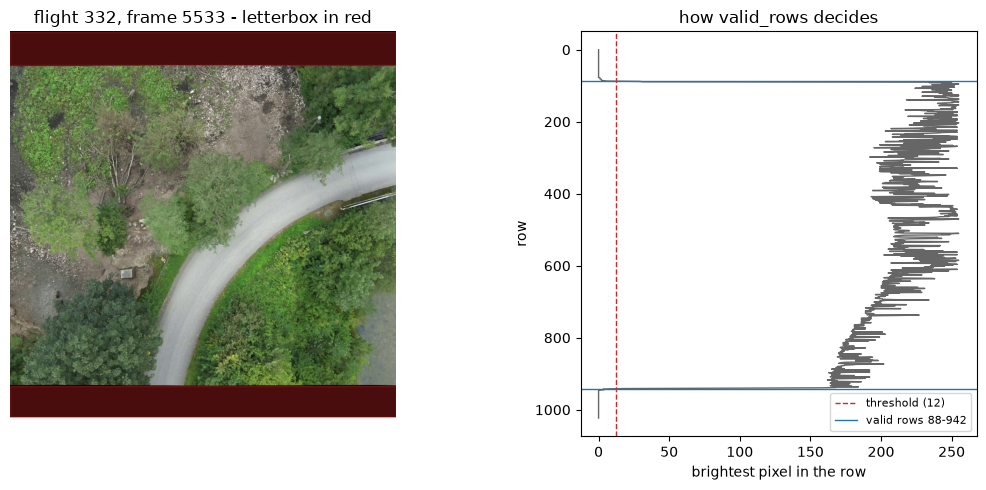

In [6]:
row_max = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={"width_ratios": [2, 1]})
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].axhspan(0, top, color="tab:red", alpha=0.35)
axes[0].axhspan(bot, img.shape[0], color="tab:red", alpha=0.35)
axes[0].set_title(f"flight {FLIGHT}, frame {FRAME} - letterbox in red")
axes[0].axis("off")

axes[1].plot(row_max, np.arange(len(row_max)), lw=1, color="0.4")
axes[1].axvline(12, color="tab:red", ls="--", lw=1, label="threshold (12)")
axes[1].axhline(top, color="tab:blue", lw=1)
axes[1].axhline(bot, color="tab:blue", lw=1, label=f"valid rows {top}-{bot}")
axes[1].invert_yaxis()
axes[1].set_xlabel("brightest pixel in the row")
axes[1].set_ylabel("row")
axes[1].set_title("how valid_rows decides")
axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

The bands are not exactly zero, which is why the test is against a small
threshold rather than against zero. Compression bleeds a little brightness into
them and the edge is a ramp rather than a step — on this frame the brightest
pixel per row runs `1, 1, 2, 2, 2, 2, 4, 6, 29, 32, 250` across rows 80 to 90.
A threshold of 12 sits in the gap between the bleed and the imagery.

<a id="4"></a>
## 4. Scale, and why two models are resampled

BAMBI is far higher resolution than the imagery these models were built for.
Estimated from 96,746 annotated animal boxes across seven species of known body
length, the ground sampling distance is a **median of 3.5 cm/px** (p10 2.3,
p90 4.8; per flight 1.4 to 9.8), so a 1024 px frame covers only about
**36 x 36 m**.

Both SegFormer models expect much coarser imagery, and both upstream projects
downsample to a fixed resolution before inference. That is reproduced here
rather than feeding either network a scale it never saw in training. SAM 3 has
no such expectation and runs at native resolution.

In [7]:
GSD_CM = 3.5      # median for the release; see docs/environment.md

print(f"{'model':<26}{'native GSD':>12}{'target':>9}{'scale':>8}"
      f"{'input size':>14}")
for cls in (es.TreeCoverSegmenter, es.DeadwoodSegmenter):
    scale = GSD_CM / cls.target_gsd_cm
    h, w = int((bot - top) * scale), int(img.shape[1] * scale)
    print(f"{cls.class_name:<26}{GSD_CM:>9.1f} cm{cls.target_gsd_cm:>7.0f} cm"
          f"{scale:>8.3f}{f'{w}x{h}':>14}")
print(f"{'SAM 3 (8 classes)':<26}{GSD_CM:>9.1f} cm{'native':>9}{1.0:>8.3f}"
      f"{f'{img.shape[1]}x{bot - top}':>14}")

print(f"\nA frame covers about {img.shape[1] * GSD_CM / 100:.0f} x "
      f"{(bot - top) * GSD_CM / 100:.0f} m on the ground.")

model                       native GSD   target   scale    input size
tree cover                      3.5 cm     10 cm   0.350       358x298
deadwood                        3.5 cm      5 cm   0.700       716x597
SAM 3 (8 classes)               3.5 cm   native   1.000      1024x854

A frame covers about 36 x 30 m on the ground.


Per-flight GSD varies by a factor of seven, so for a flight far from the median
it is worth passing your own estimate — every model call takes `gsd_cm`.

<a id="5"></a>
## 5. Running the three models

Each model is one class with one call. The cells below are the real thing, but
they need a GPU and the two checkpoints, so they are guarded: set `RUN_MODELS`
and fill in the paths to run them.

* **SAM 3** needs the `sam3` package and its checkpoint, which is gated on
  HuggingFace. The backbone is encoded once per frame and each prompt is then
  a cheap pass over the cached features, so asking for all eight classes costs
  far less than eight times one class.
* **Tree cover** pulls `restor/tcd-segformer-mit-b5` from HuggingFace on first
  use; nothing is gated.
* **Deadwood** needs the deadtrees.earth checkpoint as a local `.safetensors`
  file.

In [8]:
RUN_MODELS = False                       # set True if you have a GPU
SAM3_CHECKPOINT = "sam3.pt"              # gated: facebook/sam3 on HuggingFace
DEADWOOD_CHECKPOINT = "deadwood_segformer_b5.safetensors"

if RUN_MODELS:
    sam3 = es.Sam3Segmenter(SAM3_CHECKPOINT)
    masks = sam3(img)                            # all eight, one backbone pass
    tc = es.TreeCoverSegmenter()
    masks["tree cover"] = tc(img, gsd_cm=GSD_CM)
    dw = es.DeadwoodSegmenter(DEADWOOD_CHECKPOINT)
    masks["deadwood"] = dw(img, gsd_cm=GSD_CM)
    masks = {c: m for c, m in masks.items() if m.any()}
    print({c: round(es.coverage(m, (top, bot)), 4) for c, m in masks.items()})
else:
    print("RUN_MODELS is False - using the masks shipped with the repository.")
    print("Everything below works either way; section 6 shows they are the same.")

RUN_MODELS is False - using the masks shipped with the repository.
Everything below works either way; section 6 shows they are the same.


<a id="6"></a>
## 6. Does it reproduce the release?

The claim that this module is what produced the release should be checked
rather than believed, so the repository ships the output of running it over a
**dense run of 34 frames** from flight 332 — every fifth frame from 5450 to
5600, plus the five key frames that do not fall on that grid.

Five of those 34 frames are published key frames. The frames were extracted
from the same video with the same encoder settings, so they are byte-identical
to the ones the release was computed from, and the masks can be compared
directly.

In [9]:
dense = es.load_masks("examples/environment/flight332_dense.json.gz")
frames = sorted(dense["masks"])
overlap = [f for f in frames if f in published]

print(f"example frames    : {len(frames)}  ({frames[0]} to {frames[-1]})")
print(f"also published    : {len(overlap)}  {overlap}")
print()
print(f"{'frame':>7}  {'class':<12}{'IoU':>7}")
ious = []
for f in overlap:
    for c in sorted(set(dense["masks"][f]) | set(published[f])):
        a, b = dense["masks"][f].get(c), published[f].get(c)
        if a is None and b is None:
            continue
        v = 0.0 if a is None or b is None else es.iou(a, b)
        ious.append(v)
        print(f"{f:>7}  {c:<12}{v:>7.4f}")

print(f"\n{len(ious)} masks compared, "
      f"{sum(1 for v in ious if v == 1.0)} pixel-identical, "
      f"min IoU {min(ious):.4f}")

example frames    : 34  (5450 to 5600)
also published    : 5  [5458, 5533, 5567, 5570, 5585]

  frame  class           IoU
   5458  bare ground  1.0000
   5458  grass        1.0000
   5458  road         1.0000
   5458  rock         1.0000
   5458  tree cover   1.0000
   5533  bare ground  1.0000
   5533  grass        1.0000
   5533  road         1.0000
   5533  rock         1.0000
   5533  tree cover   1.0000
   5533  water        1.0000
   5567  bare ground  1.0000
   5567  grass        1.0000
   5567  road         1.0000
   5567  rock         1.0000
   5567  tree cover   1.0000
   5567  water        1.0000
   5570  bare ground  1.0000
   5570  grass        1.0000
   5570  road         1.0000
   5570  rock         1.0000
   5570  tree cover   1.0000
   5570  water        1.0000
   5585  bare ground  1.0000
   5585  grass        1.0000
   5585  road         1.0000
   5585  rock         1.0000
   5585  tree cover   1.0000
   5585  water        1.0000

29 masks compared, 29 pixel-identic

Every mask is identical, so the recipe in section 5 is exactly the one behind
the published files, and anything you compute with it on other frames sits on
the same footing as the release.

<a id="7"></a>
## 7. What you gain between the key frames

Here is the point of the exercise. The published series for this stretch of
flight 332 has five samples; the dense run has 34 over the same 150 frames —
five seconds of video.

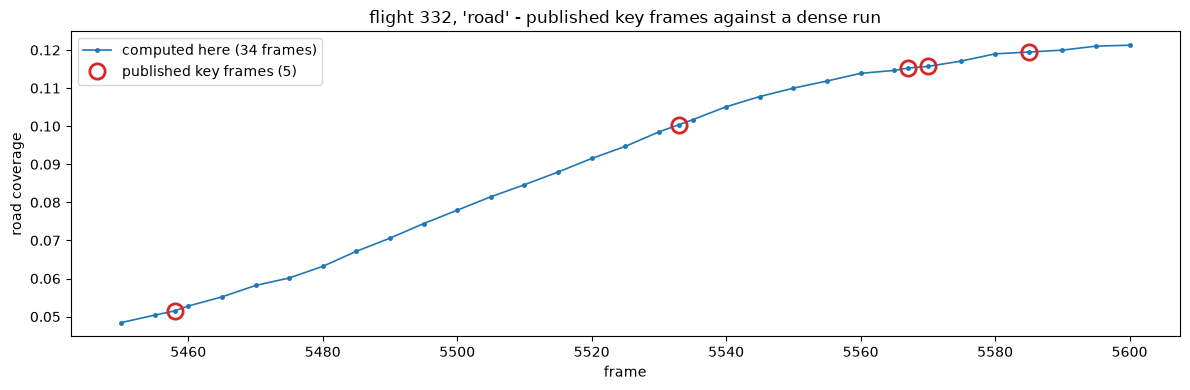

published samples over frames 5450-5600 : 5
dense samples over the same range     : 34
coverage range, published             : 0.052 to 0.119
coverage range, dense                 : 0.048 to 0.121


In [10]:
CLS = "road"
lo, hi = frames[0], frames[-1]

dx = frames
dy = [es.coverage(dense["masks"][f].get(
        CLS, np.zeros((1024, 1024), bool)), (top, bot)) for f in dx]
px = [f for f in sorted(published) if lo <= f <= hi]
py = [es.coverage(published[f].get(
        CLS, np.zeros((1024, 1024), bool)), (top, bot)) for f in px]

plt.figure(figsize=(12, 4))
plt.plot(dx, dy, ".-", lw=1.2, ms=5, color="tab:blue",
         label=f"computed here ({len(dx)} frames)")
plt.plot(px, py, "o", ms=11, mfc="none", mew=2, color="tab:red",
         label=f"published key frames ({len(px)})")
plt.xlabel("frame"); plt.ylabel(f"{CLS} coverage")
plt.title(f"flight {FLIGHT}, '{CLS}' - published key frames against a dense run")
plt.legend(); plt.tight_layout(); plt.show()

print(f"published samples over frames {lo}-{hi} : {len(px)}")
print(f"dense samples over the same range     : {len(dx)}")
print(f"coverage range, published             : "
      f"{min(py):.3f} to {max(py):.3f}")
print(f"coverage range, dense                 : "
      f"{min(dy):.3f} to {max(dy):.3f}")

The five published points sit exactly on the dense curve, because they are the
same frames — section 6 just showed the masks are identical. What the dense run
adds is the shape between them: a smooth, almost monotonic rise as the drone
comes over the road, from 5% to 12% coverage in five seconds.

That shape is the reassuring answer. Over this stretch the scene really does
change slowly and the key frames are not hiding anything, so the dense run
buys not a different answer but a better constrained one — the smoothing and
stability flags in section 9 have 34 samples to work with instead of 5.

Two frames from the run, one published and one not:

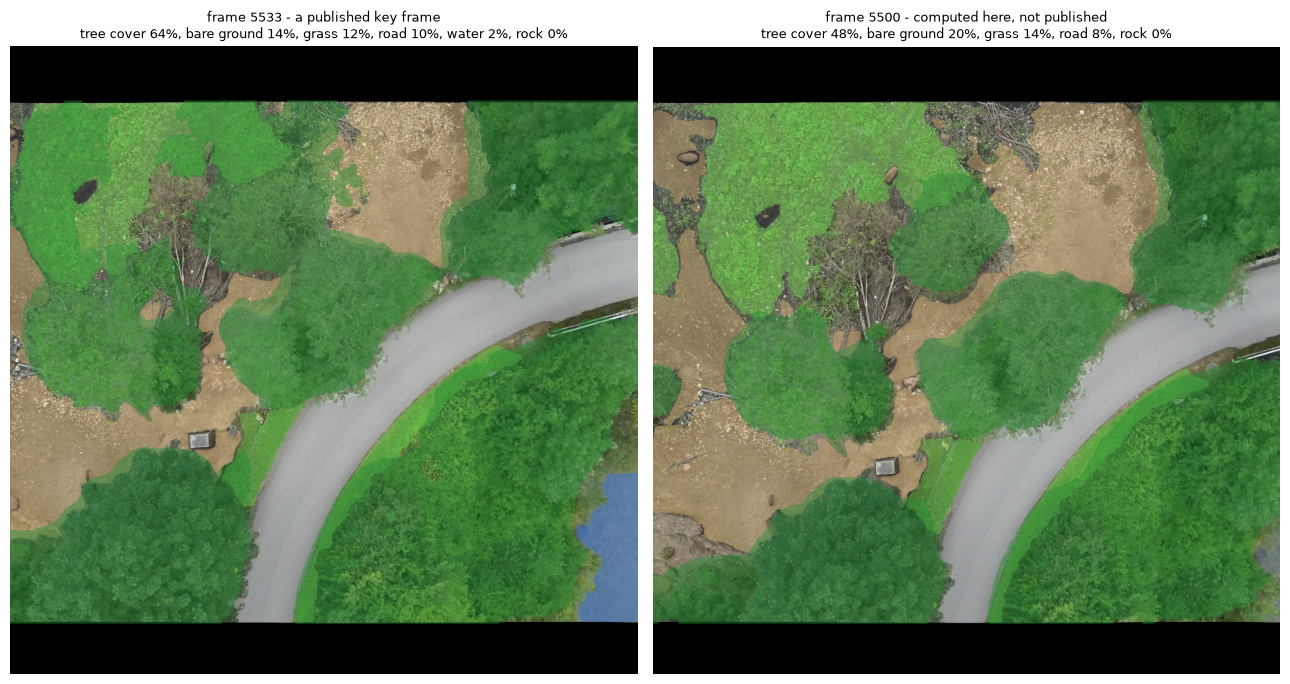

In [11]:
COLOURS = {"snow": (0.42, 0.78, 0.92), "water": (0.20, 0.45, 0.85),
           "grass": (0.45, 0.80, 0.35), "road": (0.60, 0.60, 0.60),
           "rock": (0.70, 0.55, 0.40), "bare ground": (0.85, 0.70, 0.45),
           "roof": (0.90, 0.35, 0.35), "vehicle": (0.95, 0.75, 0.20),
           "tree cover": (0.15, 0.55, 0.20), "deadwood": (0.85, 0.25, 0.25)}


def draw(ax, frame_no, title):
    subprocess.run([sys.executable, "frame_extraction.py", str(video),
                    str(WORK), "--start", str(frame_no),
                    "--end", str(frame_no + 1), "--rgb"],
                   capture_output=True, text=True)
    f = cv2.imread(str(WORK / "rgb" / f"{FLIGHT}_{frame_no:08d}.png"))
    out = cv2.cvtColor(f, cv2.COLOR_BGR2RGB).astype(float) / 255
    present = {}
    for cls, m in dense["masks"][frame_no].items():
        out[m] = 0.55 * out[m] + 0.45 * np.array(COLOURS.get(cls, (1, 0, 1)))
        present[cls] = es.coverage(m, (top, bot))
    ax.imshow(out); ax.axis("off")
    ax.set_title(f"{title}\n" + ", ".join(
        f"{k} {100 * v:.0f}%" for k, v in
        sorted(present.items(), key=lambda kv: -kv[1])), fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(13, 6.8))
draw(axes[0], 5533, "frame 5533 - a published key frame")
draw(axes[1], 5500, "frame 5500 - computed here, not published")
plt.tight_layout(); plt.show()

<a id="8"></a>
## 8. Back to the published format

Masks computed here can be written in exactly the format the release uses:
COCO run-length encoding, column-major, always starting with a run of zeros —
so a mask whose first pixel is set begins with a run of length 0.

In [12]:
m = dense["masks"][5500]["road"]
rle = es.rle_encode(m.astype(np.uint8))

print(f"mask         : {m.shape}, {m.sum()} pixels set")
print(f"encoded      : {len(rle['counts'])} runs, "
      f"{len(json.dumps(rle['counts']))} bytes of JSON")
print(f"round-trips  : {np.array_equal(es.rle_decode(rle), m)}")

# and the shape of a file matching the published one
doc = {
    "flight": int(FLIGHT),
    "licence": "CC-BY-4.0",
    "classes": es.SAM3_CLASSES,
    "mask_format": "COCO RLE, column-major, 1024x1024 full frame",
    "frames": [{"frame": f,
                "masks": {c: es.rle_encode(mm.astype(np.uint8))
                          for c, mm in dense["masks"][f].items()
                          if c in es.SAM3_CLASSES}}
               for f in frames],
}
out = WORK / f"{FLIGHT}_environment_dense.json"
out.write_text(json.dumps(doc))
print(f"\nwrote {out} ({out.stat().st_size / 1e6:.2f} MB, "
      f"{len(doc['frames'])} frames)")
print("re-reads as    :", len(es.load_masks(out)["masks"]), "frames")

mask         : (1024, 1024), 68159 pixels set
encoded      : 1181 runs, 5604 bytes of JSON
round-trips  : True

wrote environment_demo/332_environment_dense.json (1.11 MB, 34 frames)


re-reads as    : 34 frames


<a id="9"></a>
## 9. Flags on a dense series

The release ships three flags alongside the raw masks, because the masks are
the raw model output and are not smoothed. On frames that are one material edge
to edge — a flat snowfield, a fog whiteout — SAM 3 has no boundary to find and
its detections flicker between adjacent frames.

`es.flag_series` computes all three for one class over one series, with the
thresholds the release used. It is worth recomputing on a dense run rather than
reusing the published flags: the smoothing window is defined in **frames**, so
over key frames alone it may contain only two or three samples, while over this
run it contains far more.

In [13]:
# `es.dynamic_range(frame)` is the measurement behind the `undetermined` flag;
# the example ships it for every frame so nothing has to be re-extracted here.
ranges = [dense["dynamic_range"][f"{f:06d}"] for f in frames]

flags = es.flag_series(frames, dy, ranges=ranges, half_window=120.0)

print(f"class                  : {CLS}")
print(f"frames                 : {len(frames)}")
print(f"luminance range        : {min(ranges):.0f} to {max(ranges):.0f} "
      f"(undetermined below 90)")
print(f"undetermined           : {int(flags['undetermined'].sum())}")
print(f"unstable               : {int(flags['unstable'].sum())}")
print(f"flicker rate           : {flags['flicker']:.3f}"
      f"   unreliable: {flags['unreliable']}")

# the same statistic over the published key frames alone, for comparison
pf = es.flag_series(px, py, half_window=120.0)
print(f"\nflicker over the 5 published frames in this range: {pf['flicker']:.3f}")
print("A rate estimated from 5 samples is not worth much; this is the other")
print("reason to compute the frames in between.")

class                  : road
frames                 : 34
luminance range        : 146 to 154 (undetermined below 90)
undetermined           : 0
unstable               : 0
flicker rate           : 0.030   unreliable: False

flicker over the 5 published frames in this range: 0.000
A rate estimated from 5 samples is not worth much; this is the other
reason to compute the frames in between.


<a id="10"></a>
## 10. Cost, and what to watch for

On one V100, for a 1024x1024 frame: SAM 3 with all eight prompts is the
expensive one at roughly 2 s per frame, tree cover and deadwood a few hundred
milliseconds each. The 34-frame example above took about two minutes end to
end including model loading. A whole flight at every frame — 10,634 frames for
this one — is several hours on one card, which is precisely why the release
stops at the key frames.

Three things to keep in mind if you extend this:

* **Do not skip `valid_rows`.** It is the difference between a coverage figure
  and a coverage figure that is 8% letterbox.
* **Pass a per-flight `gsd_cm`** when the flight is far from the 3.5 cm median.
  The two SegFormer models resample relative to it, so a wrong value feeds them
  the wrong scale, and per-flight GSD spans 1.4 to 9.8 cm.
* **Recompute the flags, do not interpolate them.** `unstable` compares a frame
  against its temporal neighbourhood; if you add frames, the neighbourhood
  changes and the old flags no longer describe it.

And the licence, once more: the eight SAM 3 classes are CC-BY-4.0, but tree
cover and deadwood are research and evaluation only, and that restriction
follows any mask you produce with them. See
[docs/dataset-versions.md](docs/dataset-versions.md#licensing-and-why-the-environment-layers-are-split-in-two)
for the full chain, and [docs/environment.md](docs/environment.md) for what
each class means and where each one fails.